## Task 1

In [35]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, f1_score, accuracy_score
import matplotlib.pyplot as plt


heart_df = pd.read_csv('heart_disease.csv')

In [36]:
heart_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       270 non-null    int64  
 1   sex       270 non-null    int64  
 2   cp        270 non-null    int64  
 3   trestbps  270 non-null    int64  
 4   chol      270 non-null    int64  
 5   fbs       270 non-null    int64  
 6   restecg   270 non-null    int64  
 7   thalach   270 non-null    int64  
 8   exang     270 non-null    int64  
 9   oldpeak   270 non-null    float64
 10  slope     270 non-null    int64  
 11  ca        270 non-null    int64  
 12  thal      270 non-null    int64  
 13  target    270 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 29.7 KB


## Task 2

In [37]:
heart_df['target'].value_counts(normalize=True)

target
0    0.555556
1    0.444444
Name: proportion, dtype: float64

If we have a model that guesses no heart disease it will get it right 55%. Its a bad flag because it would miss sick patients.

## Task 3

In [38]:
features = ['age', 'trestbps', 'chol', 'thalach']
target  = 'target'
X = heart_df[features]
y = heart_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state = 42
)
X_train.shape

(216, 4)

In [39]:
X_test.shape

(54, 4)

 ## Task 4

In [40]:
lr_model = LogisticRegression(max_iter = 1000)
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)
lr_accuracy = lr_model.score(X_test, y_test)

print(f'Logistic Regression accuracy: {lr_accuracy}')

Logistic Regression accuracy: 0.6666666666666666


Yes it would be more accurate.

## Task 5

In [41]:
proba = lr_model.predict_proba(X_test)
print(proba[:5])

[[0.58906591 0.41093409]
 [0.53689401 0.46310599]
 [0.83980151 0.16019849]
 [0.74454781 0.25545219]
 [0.4218344  0.5781656 ]]


We printed out 5 patients and one of them that was sure was no heart disease on row 3. Patient 1 was close in determing where they had heart disease.


## Task 6

In [42]:
dt_model = DecisionTreeClassifier(max_depth=4, random_state = 42)
dt_model.fit(X_train, y_train)

print(dt_model.score(X_test, y_test))
print(dt_model.score(X_train, y_train))




0.6481481481481481
0.7777777777777778


In [43]:
dt_model_nolimit = DecisionTreeClassifier(random_state = 42)
dt_model_nolimit.fit(X_train, y_train)

print(dt_model_nolimit.score(X_test, y_test))
print(dt_model_nolimit.score(X_train, y_train))




0.5555555555555556
1.0


The perfectly fit (1.0) model indicates there is overfitting. The model with no depth limit can ask an unlimited amount of questions to memorize the answer. Both models scored worse on the test set. Adding columns to the model could potentially improve the accuracy.  

## Task 7 Look at the Four Kinds of Mistakes

In [44]:
cm = confusion_matrix( y_test, lr_pred)
print(cm)

[[25  8]
 [10 11]]


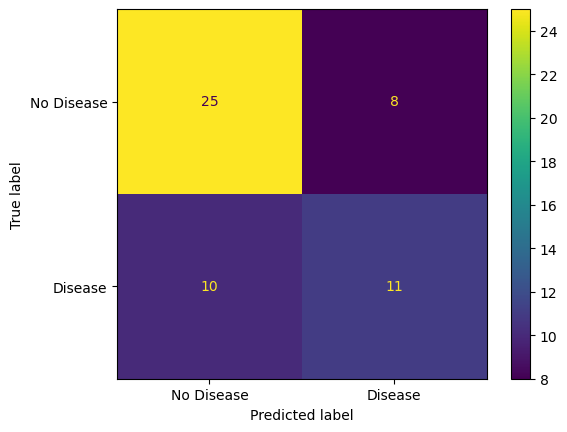

In [45]:
disp = ConfusionMatrixDisplay( confusion_matrix=cm, display_labels=['No Disease', 'Disease'])
disp.plot()
plt.show()

The most dangerous cell in this is the top right (False Negative) because you do not want to miss any patients with heart disease by marking them as healthy when they are not. The model said 8 people were healthy but they actually had heart disease. 

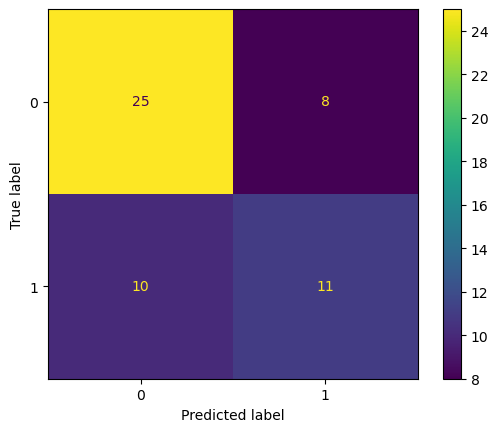

In [46]:
ConfusionMatrixDisplay.from_predictions(y_test, lr_pred)
plt.show()

## Task 8 Measure Precision and Recall

In [47]:
prec = precision_score( y_test, lr_pred)
print("Precision", prec) 

Precision 0.5789473684210527


In [48]:
recall= recall_score(y_test, lr_pred)
print("Recall:", recall)

Recall: 0.5238095238095238


For this model recall is more important because it tells us how much heart disease the model successfully caught. It tells you how many of the real positives you caught. 

## Task 9: Turn the Dial Toward Catching more Sick Patients

In [53]:
proba_heart = proba[:,1]
threshold = 0.3
y_pred_low = (proba_heart >= threshold).astype(int)
prec_low = precision_score(y_test, y_pred_low)
rec_low = recall_score(y_test, y_pred_low)
accuracy_low= accuracy_score(y_test, y_pred_low)
print("Low Precision", prec_low)
print("Low Recall:", rec_low)
print("standard Precision", prec)
print("Standard Recall", recall)
print("Low accuracy", accuracy_low)

Low Precision 0.5405405405405406
Low Recall: 0.9523809523809523
standard Precision 0.5789473684210527
Standard Recall 0.5238095238095238
Low accuracy 0.6666666666666666


Recall increased and precision slightly decreased. This tradeoff is worth it for this study because we want to make sure we catch all of the patients that are positive for heart disease.  You will get more false positives with this cutoff change

## Task 10: Recommend One Model and One Cutoff


In [50]:
dt_model_pred = dt_model.predict(X_test)

In [ ]:
print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, lr_pred))
print("Precision:", precision_score(y_test, lr_pred))
print("Recall:", recall_score(y_test, lr_pred))
print("F1:", f1_score(y_test, lr_pred)) # Harmonic mean of precision and recall


print()


print("Decision Tree")
print("Accuracy:", accuracy_score(y_test, dt_model_pred))
print("Precision:", precision_score(y_test, dt_model_pred))
print("Recall:", recall_score(y_test, dt_model_pred))
print("F1:", f1_score(y_test, dt_model_pred))

Logistic Regression
Accuracy: 0.6666666666666666
Precision: 0.5789473684210527
Recall: 0.5238095238095238
F1: 0.55

Decision Tree
Accuracy: 0.6481481481481481
Precision: 0.5416666666666666
Recall: 0.6190476190476191
F1: 0.5777777777777777


I would use the logistics regression with the .3 cutoff (high recall) to try and get rid of the false negatives even though the accuracy . This model came back with the highest accuracy